In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("train1.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
## Basic Dataset Inspection

print(df.columns.tolist())

['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC'

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
## Missing Values

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
## Target Variable Check.

print("SalePrice statistics:")
print(df['SalePrice'].describe())

SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


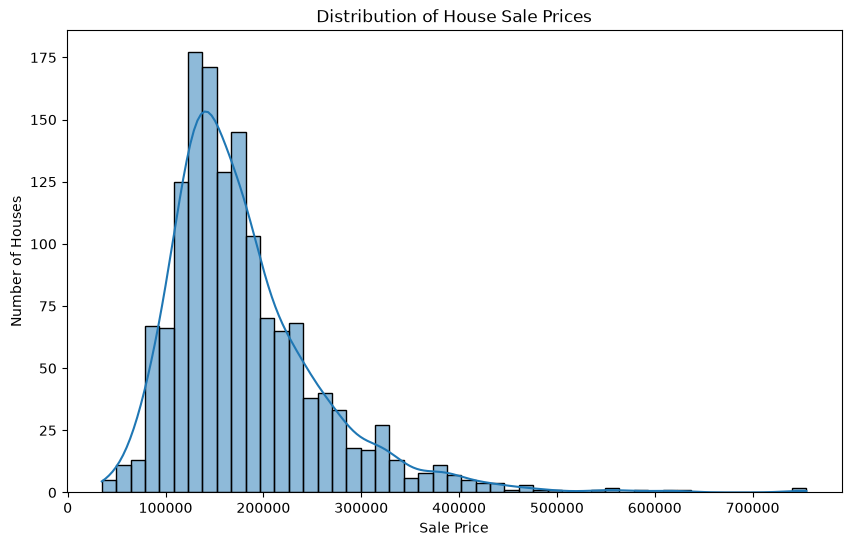

In [12]:
## SalePrice Distribution

plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Number of Houses')

plt.show()

In [ ]:
### Observation

The distribution of SalePrice shows how house prices are distributed in the dataset. The shape of the distribution helps identify whether prices are evenly distributed or skewed toward lower or higher values.

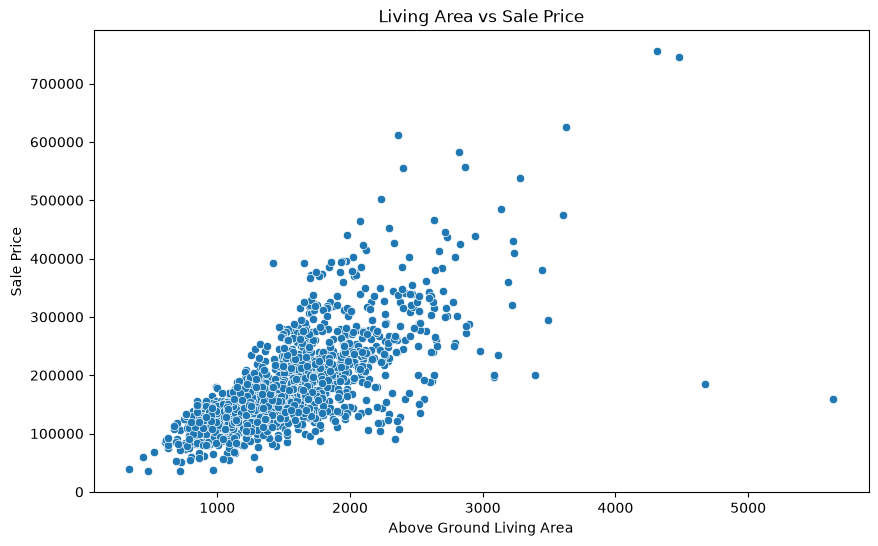

In [14]:
## House Area vs Sale Price

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='SalePrice'
)

plt.title('Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area')
plt.ylabel('Sale Price')

plt.show()

In [ ]:
### Observation

The scatter plot shows the relationship between above-ground living area and house sale price. Generally, larger living areas tend to be associated with higher house prices, although some variation and outliers can be observed.

In [16]:
## Correlation with SalePrice
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print(correlation.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


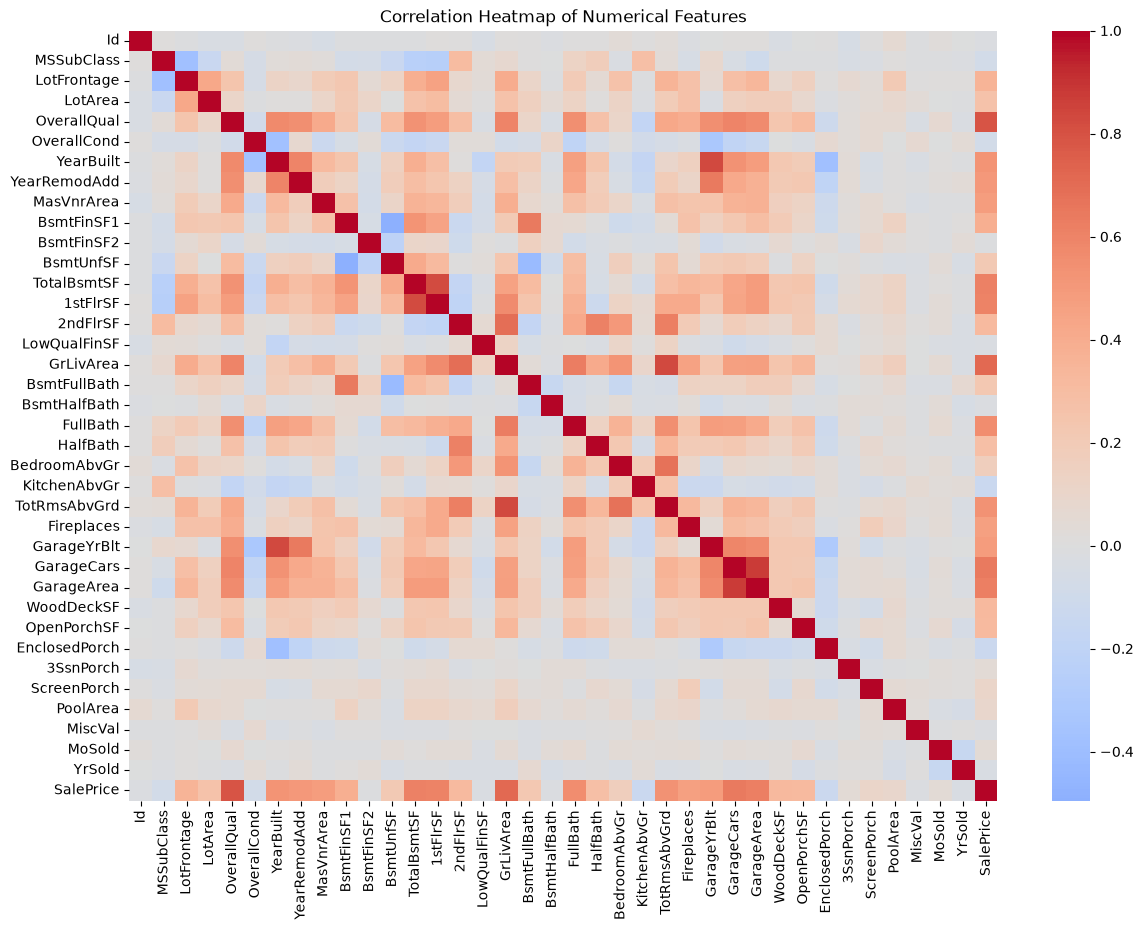

In [17]:
## Correlation Heatmap

plt.figure(figsize=(14, 10))

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)


plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [18]:
## Separate Numerical and Categorical Columns

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns


print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numerical columns: 38
Number of categorical columns: 43


C:\Users\PROFESSOR\AppData\Local\Temp\ipykernel_9900\4180646068.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [19]:
print("Numerical columns:")
print(numeric_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

Numerical columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplac

In [20]:
## Handle Missing Values
df_clean = df.copy()

In [21]:
## Numerical missing values
for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [23]:
## Categorical missing values
for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [24]:
## Check Missing Values Again
missing_after = df_clean.isnull().sum()


print("Total missing values after cleaning:",
      missing_after.sum())

Total missing values after cleaning: 0


In [25]:
print(df_clean.isnull().sum().sort_values(ascending=False).head(20))

Id              0
MSSubClass      0
MSZoning        0
LotFrontage     0
LotArea         0
Street          0
Alley           0
LotShape        0
LandContour     0
Utilities       0
LotConfig       0
LandSlope       0
Neighborhood    0
Condition1      0
Condition2      0
BldgType        0
HouseStyle      0
OverallQual     0
OverallCond     0
YearBuilt       0
dtype: int64


In [ ]:
## Missing Value Handling

Missing values were handled according to the data type of each feature.

- Numerical features were filled using the median value. The median is less affected by extreme values than the mean.
- Categorical features were filled using the most frequent category (mode).
- Rows were not deleted because removing observations would unnecessarily reduce the size of the dataset.

After imputation, the dataset contained no missing values.

In [26]:
##  Check Data Types

print(df_clean.dtypes.value_counts())

str        43
int64      35
float64     3
Name: count, dtype: int64


In [27]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Shape:", df_clean.shape)

Missing values: 0
Duplicate rows: 0
Shape: (1460, 81)


In [28]:
## Select Features and Target

## SalePrice
X = df_clean.drop('SalePrice', axis=1)
y = df_clean['SalePrice']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [ ]:
## Feature Selection Discussion

House prices can be influenced by several property characteristics.

Important potential predictors include:

- Overall quality of the house (`OverallQual`)
- Above-ground living area (`GrLivArea`)
- Garage size (`GarageCars`)
- Garage area (`GarageArea`)
- Total basement area (`TotalBsmtSF`)
- First-floor area (`1stFlrSF`)
- Number of rooms (`TotRmsAbvGrd`)
- Year built (`YearBuilt`)
- Year of remodeling (`YearRemodAdd`)
- Neighborhood and other categorical property characteristics

These features describe the size, quality, age, location, and facilities of a property and are therefore likely to contain useful information for predicting `SalePrice`.

In [29]:
## One-Hot Encoding

## MSZoning
## Neighborhood
## HouseStyle
## GarageType
## SaleType
X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (1460, 245)


In [30]:
## Check Encoding
print(X_encoded.head())

   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  SaleType_ConLI  SaleType_ConLw  \
0          2003       196.0         706  ...               0               0   
1          1976         0.0         978  ...               0               0   
2          2002       162.0         486  ...               0               0   
3          1970         0.0         216  ...               0               0   
4          2000       350.0         655  ...               0               0   

   SaleType_New  SaleType_Oth  SaleTyp

In [31]:
print("Any missing values:", X_encoded.isnull().sum().sum())

Any missing values: 0


In [32]:
## Train/Test Split

## The internship requires an 80/20 split.

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)


print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)


print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1168, 245)
Testing features: (292, 245)
Training target: (1168,)
Testing target: (292,)


In [33]:
## Train Linear Regression

model = LinearRegression()


model.fit(X_train, y_train)


print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [34]:
## Make Predictions
y_pred = model.predict(X_test)


print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[156441.38852363 339187.42788375  86610.6537886  187116.25956568
 320803.73856029  64107.21804402 254169.98510002 145624.71308415
  53010.11069719 155793.97811054]


In [35]:
## Calculate MSE, RMSE and R²

mse = mean_squared_error(y_test, y_pred)


rmse = np.sqrt(mse)


r2 = r2_score(y_test, y_pred)


print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 1019680445.3136275
Root Mean Squared Error (RMSE): 31932.435630775606
R² Score: 0.867061658426185


In [36]:
print(f"R² Score: {r2:.4f}")
print(f"R² Score: {r2 * 100:.2f}%")

R² Score: 0.8671
R² Score: 86.71%


In [38]:
## Create an Evaluation Table
evaluation = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R²'],
    'Value': [mse, rmse, r2]
})


evaluation

,Metric,Value
0,MSE,1.019680e+09
1,RMSE,3.193244e+04
2,R²,8.670617e-01


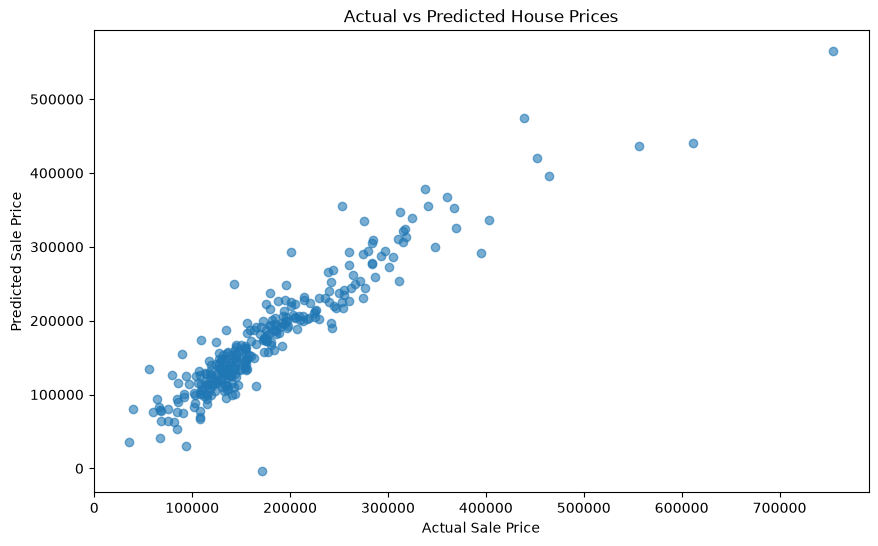

In [39]:
## Actual vs Predicted Prices


plt.figure(figsize=(10, 6))


plt.scatter(y_test, y_pred, alpha=0.6)


plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted House Prices')


plt.show()

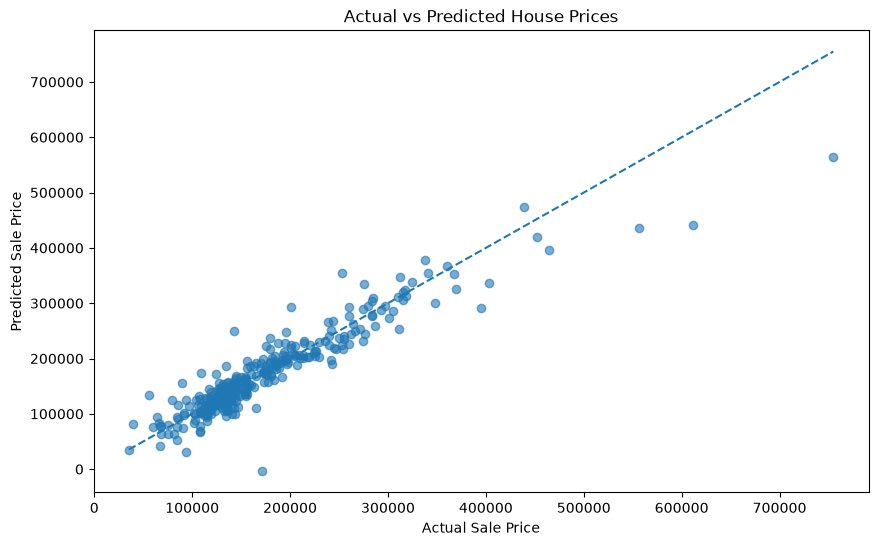

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted House Prices')

plt.show()

In [ ]:
### Actual vs Predicted Interpretation

The actual-vs-predicted plot compares the real house sale prices with the prices predicted by the Linear Regression model. Points closer to the diagonal reference line represent more accurate predictions.

In [42]:
## Residual Plot
## First calculate residuals:

residuals = y_test - y_pred

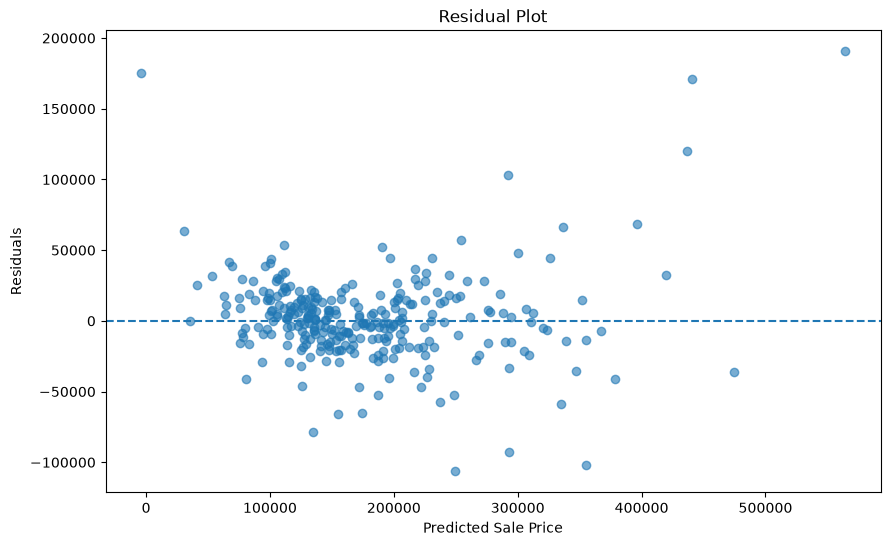

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

In [45]:
### Residual Plot Interpretation

The residual plot shows the differences between actual and predicted house prices. Residuals are calculated as the actual price minus the predicted price. A useful regression model should generally have residuals distributed around zero without a strong systematic pattern.

SyntaxError: invalid syntax (1771168578.py, line 3)

In [47]:
## Coefficient Analysis

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})


coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()


coefficients_sorted = coefficients.sort_values(
    'Absolute_Coefficient',
    ascending=False
)


coefficients_sorted.head(15)

,Feature,Coefficient,Absolute_Coefficient
225,PoolQC_Gd,-287358.642912,287358.642912
91,Condition2_PosN,-136623.601558,136623.601558
224,PoolQC_Fa,-114783.980323,114783.980323
90,Condition2_PosA,100882.827018,100882.827018
201,Functional_Sev,-100166.645477,100166.645477
117,RoofMatl_WdShngl,91675.267201,91675.267201
92,Condition2_RRAe,-80251.578648,80251.578648
106,RoofStyle_Gable,-64781.552418,64781.552418
108,RoofStyle_Hip,-62668.873544,62668.873544
184,Heating_Wall,59657.888803,59657.888803


In [48]:
## Now show the strongest positive coefficients:

positive_coefficients = coefficients.sort_values(
    'Coefficient',
    ascending=False
)


positive_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
90,Condition2_PosA,100882.827018,100882.827018
117,RoofMatl_WdShngl,91675.267201,91675.267201
184,Heating_Wall,59657.888803,59657.888803
241,SaleCondition_Alloca,56071.028264,56071.028264
229,MiscFeature_Othr,51293.663390,51293.663390
110,RoofStyle_Shed,50355.997765,50355.997765
88,Condition2_Feedr,49804.709450,49804.709450
111,RoofMatl_CompShg,47604.711373,47604.711373
165,BsmtCond_Po,45699.630755,45699.630755
77,Neighborhood_StoneBr,45293.266801,45293.266801


In [49]:
## And strongest negative coefficients:

negative_coefficients = coefficients.sort_values(
    'Coefficient',
    ascending=True
)

negative_coefficients.head(10)

,Feature,Coefficient,Absolute_Coefficient
225,PoolQC_Gd,-287358.642912,287358.642912
91,Condition2_PosN,-136623.601558,136623.601558
224,PoolQC_Fa,-114783.980323,114783.980323
201,Functional_Sev,-100166.645477,100166.645477
92,Condition2_RRAe,-80251.578648,80251.578648
106,RoofStyle_Gable,-64781.552418,64781.552418
108,RoofStyle_Hip,-62668.873544,62668.873544
107,RoofStyle_Gambrel,-57503.325330,57503.325330
49,Utilities_NoSeWa,-52161.108737,52161.108737
220,GarageCond_Po,-38612.165156,38612.165156


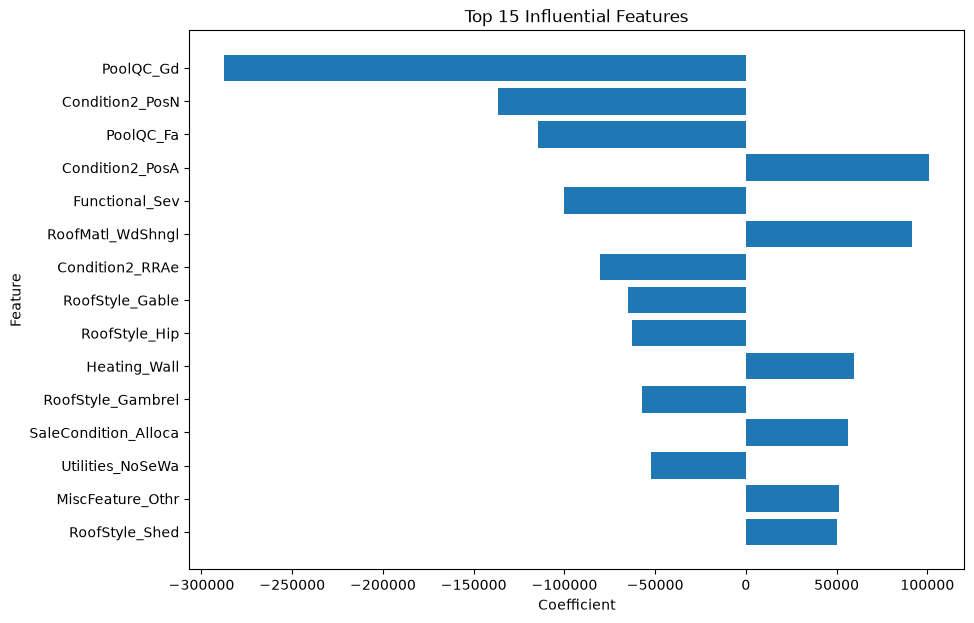

In [51]:
## Coefficient Visualization
top_coefficients = coefficients_sorted.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients['Feature'],
    top_coefficients['Coefficient']
)


plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Top 15 Influential Features')

plt.gca().invert_yaxis()

plt.show()

In [52]:
## Coefficient Analysis

The Linear Regression coefficients indicate how each feature contributes to the predicted SalePrice while other features are held constant.

Positive coefficients indicate that an increase in the corresponding feature is associated with an increase in predicted house price, while negative coefficients indicate an inverse relationship.

The features with the largest absolute coefficients are considered the most influential features in the fitted Linear Regression model.

SyntaxError: invalid syntax (2524746308.py, line 3)

In [53]:
coefficients_sorted.head(15)

,Feature,Coefficient,Absolute_Coefficient
225,PoolQC_Gd,-287358.642912,287358.642912
91,Condition2_PosN,-136623.601558,136623.601558
224,PoolQC_Fa,-114783.980323,114783.980323
90,Condition2_PosA,100882.827018,100882.827018
201,Functional_Sev,-100166.645477,100166.645477
117,RoofMatl_WdShngl,91675.267201,91675.267201
92,Condition2_RRAe,-80251.578648,80251.578648
106,RoofStyle_Gable,-64781.552418,64781.552418
108,RoofStyle_Hip,-62668.873544,62668.873544
184,Heating_Wall,59657.888803,59657.888803


In [ ]:
## Model Performance

The Linear Regression model achieved an R² score of 0.8671, meaning that approximately 86.71% of the variation in house SalePrice is explained by the features used in the model.

The model achieved an RMSE of approximately 31,932.44. This means that the typical prediction error is on the order of $31,932 in the target variable's price units.

The MSE was approximately 1.02 billion. Since MSE squares the prediction errors, it is more sensitive to large prediction errors than RMSE.

Overall, the model demonstrates a strong baseline performance for predicting house prices.

In [ ]:
## Coefficient Analysis

The coefficient analysis identifies features that have relatively large positive or negative coefficients in the Linear Regression model.

Positive coefficients indicate an increase in predicted SalePrice relative to the corresponding reference category, while negative coefficients indicate a decrease, holding other model features constant.

Because categorical variables were converted using one-hot encoding with `drop_first=True`, categorical coefficients should be interpreted relative to their omitted reference categories.

The largest absolute coefficients in this model include PoolQC_Gd, Condition2_PosN, PoolQC_Fa, Condition2_PosA, and Functional_Sev. These coefficients show which encoded features have the strongest linear effects within this particular fitted model.

In [ ]:
# Conclusion

This project developed a house price prediction model using the Ames Housing dataset.

The dataset initially contained 1,460 houses and 81 columns. Missing numerical values were handled using median imputation, while missing categorical values were replaced using the mode. Categorical variables were converted into numerical features using one-hot encoding, resulting in 245 features.

The data was divided into training and testing sets using an 80/20 split. A Linear Regression model was trained on the training data and evaluated on the test data.

The model achieved:

- **MSE:** 1,019,680,000
- **RMSE:** 31,932.44
- **R²:** 0.8671 (86.71%)

The actual-vs-predicted plot showed that many predictions were close to the ideal prediction line. The residual plot showed that most errors were distributed around zero, although some larger errors were present.

Overall, the Linear Regression model provides a strong baseline for house price prediction and demonstrates the practical use of data preprocessing, feature engineering, regression modeling, and model evaluation.